# PN+Microbiome IMC Data Analysis
ichaudry

June 9th, 2026

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import find_boundaries
import matplotlib.colors as mcolors
import tifffile
import scikit_posthocs as sp
from scipy.stats import kruskal
from sklearn.mixture import GaussianMixture
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
from itertools import combinations

In [141]:
# read in the data
# all files/samples
'''PN_L_ROI = ['IMC2_002', 'IMC3_002', 'IMC3_004', 'IMC4_005', 'IMC5_005', 'IMC6_004', 'IMC1_003', 'IMC1_004', 'IMC7_003', 'IMC8_001', 'IMC9_004', 'IMC9_005', 'IMC10_004', 'IMC10_005', 'IMC11_003', 'IMC11_004', 'IMC12_003', 'IMC12_004', 'IMC13_001', 'IMC13_003', 'IMC14_003', 'IMC14_004', 'IMC15_003', 'IMC15_004', 'IMC16_004']
PN_NL_ROI = ['IMC1_001', 'IMC1_002', 'IMC2_002', 'IMC3_001', 'IMC3_003', 'IMC4_004', 'IMC5_004', 'IMC6_003', 'IMC8_005','IMC9_002', 'IMC9_003', 'IMC10_003', 'IMC11_001', 'IMC11_002', 'IMC12_002', 'IMC12_005', 'IMC13_002', 'IMC13_004', 'IMC14_002', 'IMC15_001', 'IMC15_002', 'IMC16_001']
HC_ROI = ['IMC2_005', 'IMC3_005', 'IMC4_003', 'IMC5_001', 'IMC6_001','IMC7_001', 'IMC8_003', 'IMC14_001', 'IMC15_005']'''

PN_L_ROI = ['IMC8_001', 'IMC15_004', 'IMC1_004', 'IMC14_004', 'IMC15_003', 'IMC13_001', 'IMC16_004', 'IMC9_005', 'IMC10_004']
PN_NL_ROI = ['IMC8_005', 'IMC10_003', 'IMC15_001', 'IMC1_001', 'IMC15_002', 'IMC13_002']#, 'IMC16_001']
HC_ROI = ['IMC2_005', 'IMC3_005', 'IMC4_003', 'IMC5_001', 'IMC6_001','IMC7_001', 'IMC8_003', 'IMC14_001', 'IMC15_005']

sample_group_df = pd.DataFrame(
    [
        {'sample': sample, 'group': 'PN_L_ROI'} for sample in PN_L_ROI
    ]
    + [
        {'sample': sample, 'group': 'PN_NL_ROI'} for sample in PN_NL_ROI
    ]
    + [
        {'sample': sample, 'group': 'HC_ROI'} for sample in HC_ROI
    ]
)


#read in all sample data
to_concat = []
for f in sample_group_df['sample']:
    to_concat.append(
        pd.read_csv(f'./roi_output/{f}/{f}_cells.csv')
    )

all_cells = pd.concat(to_concat, ignore_index=True)
all_cells = pd.merge(all_cells, sample_group_df, right_on='sample', left_on='roi')
all_cells = all_cells.drop(columns=['label', 'area', 'eccentricity', 'perimeter', 'solidity','centroid_y', 'centroid_x', 'area_um2', 'sample'])
all_cells = all_cells[['roi', 'compartment', 'group'] + list(all_cells.columns[2:-1])]
all_cells.columns = [c.split('_')[-1] for c in all_cells.columns]
all_cells.rename(columns={'IL7':'IL17', 'IL7RA':'IL17RA'}, inplace=True)

# split all cells into dermal and epidermal
dermal_cells = all_cells[~(all_cells['compartment'] == 'epidermis')]
epidermal_cells = all_cells[all_cells['compartment'] == 'epidermis']


### PCA

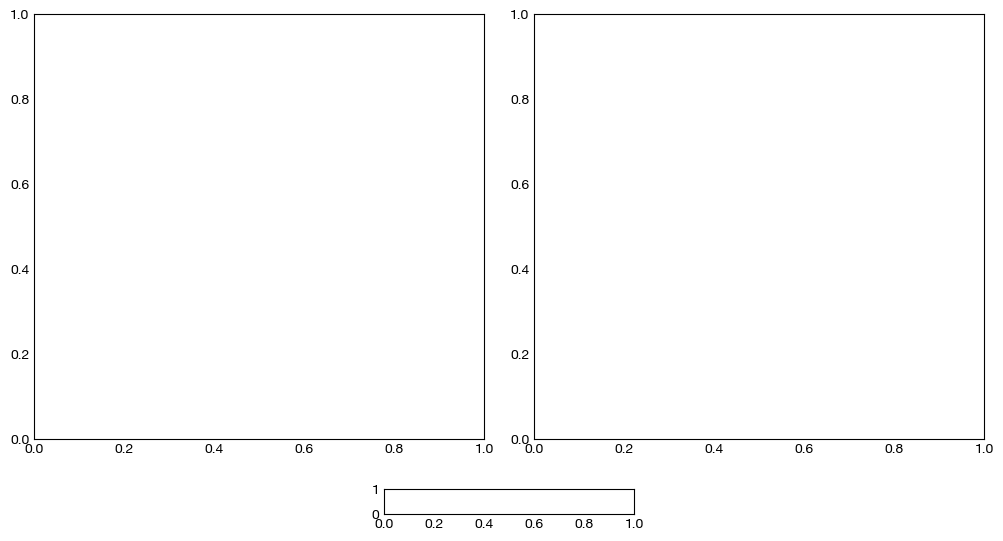

In [142]:
### pca of cells per compartment labeled by group

#make the figure
# figure size
WIDTH = 10
HEIGHT = 5

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))

### add the axes
ax_dermis =  fig.add_axes([0.55, 0.05, 0.45, 0.85])
ax_epidermis = fig.add_axes([0.05, 0.05, 0.45, 0.85])
ax_legend = fig.add_axes([0.40, -0.1, 0.25, 0.05])


In [143]:
z_order = ['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']
palette = ['#a62703', '#92c4e0', '#017d0e']
color_map = dict(zip(z_order, palette))

pca = PCA(n_components=2)
scaler = StandardScaler()

# plot the dermis pca
dermal_scaled = scaler.fit_transform(dermal_cells.drop(columns=['roi', 'compartment', 'group']))
dermal_cells_pca = pd.DataFrame(pca.fit_transform(dermal_scaled))
dermal_cells_pca = pd.concat([
    dermal_cells['group'].reset_index(drop=True), dermal_cells_pca
], axis=1)
dermis_var = pca.explained_variance_ratio_  # capture after fit

ax = ax_dermis
for group in z_order:
    subset = dermal_cells_pca[dermal_cells_pca['group'] == group]
    ax.scatter(subset[0], subset[1], label=group, color=color_map[group], zorder=z_order.index(group), s=5, alpha=0.5)
ax.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
ax.set_title("Dermis")


# plot the epidermis pca
epidermal_scaled = scaler.fit_transform(epidermal_cells.drop(columns=['roi', 'compartment', 'group']))
epidermal_cells_pca = pd.DataFrame(pca.fit_transform(epidermal_scaled))
epidermal_cells_pca = pd.concat([
    epidermal_cells['group'].reset_index(drop=True), epidermal_cells_pca
], axis=1)
epidermis_var = pca.explained_variance_ratio_  # capture after fit

ax = ax_epidermis
for group in z_order:
    subset = epidermal_cells_pca[epidermal_cells_pca['group'] == group]
    ax.scatter(subset[0], subset[1], label=group, color=color_map[group], zorder=z_order.index(group), s=5, alpha=0.5)
ax.set_xlabel(f'PC1 ({epidermis_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({epidermis_var[1]*100:.1f}%)')
ax.set_title('Epidermis')


# legend on its own axes
patches = [mpatches.Patch(color=color_map[g], label=g) for g in z_order]
ax_legend.legend(handles=patches, loc='center', ncol=len(z_order), frameon=False)
ax_legend.axis('off')


fig.savefig('all_cells_compartment_pca2.pdf', bbox_inches='tight')

### Specific marker investigation

In [123]:
def plot_marker_by_cell(roi, marker_col,
                        compartment="dermis",
                        ax=None,
                        cmap="hot",
                        percentile=(1, 99),
                        title=None,
                        show_boundaries=True,
                        boundary_color="white",
                        boundary_alpha=0.5,
                        dna_context=True,
                        dna_col="DNA1",
                        dna_alpha=0.25):
    """
    Color each cell by its marker intensity, restricted to a compartment,
    with optional DNA background and cell boundary overlays.

    Layers (bottom → top): DNA grayscale → marker values → cell boundaries.
    """

    # ── load inputs ──────────────────────────────────────────────────────────
    mask_path = f'./roi_output/{roi}/{roi}_cell_masks.tiff'
    masks = tifffile.imread(mask_path)
    df = pd.read_csv(f'./roi_output/{roi}/{roi}_cells.csv')
    df.columns = [c.split('_')[-1] for c in df.columns]
    df.rename(columns={'IL7':'IL17', 'IL7RA':'IL17RA'}, inplace=True)

    df_all = df.copy()                                  # keep all cells for DNA context
    df_filt = df[df["compartment"] == compartment] if compartment else df

    n_labels = int(masks.max()) + 1

    # ── helper: paint a value per cell across the mask image ─────────────────
    def paint(label_array, value_array):
        lut = np.full(n_labels, np.nan, dtype=np.float32)
        lut[label_array] = value_array
        return lut[masks]

    value_image = paint(df_filt["label"].values, df_filt[marker_col].values)
    dna_image   = (paint(df_all["label"].values, df_all[dna_col].values)
                   if dna_context and dna_col in df_all.columns else None)

    # ── axis setup ───────────────────────────────────────────────────────────
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), facecolor="black")

    valid = value_image[~np.isnan(value_image)]
    if len(valid) == 0:
        ax.text(0.5, 0.5, f"No {compartment} cells", color="white",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_facecolor("black"); ax.axis("off"); return ax

    ax.set_facecolor("black")

    # ── layer 1: DNA context (faint grayscale, all cells) ───────────────────
    if dna_image is not None:
        dna_valid = dna_image[~np.isnan(dna_image)]
        dna_lo, dna_hi = np.percentile(dna_valid, [5, 99])
        gray_cmap = plt.get_cmap("gray").copy()
        gray_cmap.set_bad(alpha=0)                      # NaN → transparent
        ax.imshow(dna_image, cmap=gray_cmap,
                  vmin=dna_lo, vmax=dna_hi,
                  alpha=dna_alpha, interpolation="nearest")

    # ── layer 2: marker values (the main image) ─────────────────────────────
    lo, hi = np.percentile(valid, percentile)
    marker_cmap = plt.get_cmap(cmap).copy()
    marker_cmap.set_bad(alpha=0)                        # NaN → transparent
    im = ax.imshow(value_image, cmap=marker_cmap,
                   vmin=lo, vmax=hi, interpolation="nearest")

    # ── layer 3: cell boundaries ────────────────────────────────────────────
    if show_boundaries:
        if compartment:
            keep = np.isin(masks, df_filt["label"].values)
            mask_for_bd = np.where(keep, masks, 0)
        else:
            mask_for_bd = masks
        bd = find_boundaries(mask_for_bd, mode="outer")
        rgba = np.zeros((*bd.shape, 4), dtype=np.float32)
        rgba[bd, :3] = mcolors.to_rgb(boundary_color)
        rgba[bd,  3] = boundary_alpha
        ax.imshow(rgba, interpolation="nearest")

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label=marker_col)
    #ax.set_title(title or f"{marker_col}  ({compartment or 'all cells'})",
    #             color="white", fontsize=11)
    ax.axis("off")
    return ax

In [144]:
### pca of dermal cells, colored by marker intensity + box plots

def pca_box_target_es_d_ttest_norm(TARGET):
    from scipy.stats import mannwhitneyu
    from scipy.stats import ttest_ind

    # figure size
    WIDTH = 8
    HEIGHT = 8

    # figure style
    plt.rcParams.update(plt.rcParamsDefault)
    %matplotlib inline
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 10
    plt.rcParams['xtick.major.size'] = 0
    plt.rcParams['ytick.major.size'] = 0
    plt.rcParams['pdf.fonttype'] = 42

    z_order = ['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']

    fig = plt.figure(figsize=(WIDTH, HEIGHT))

    ### add the axes
    ax_pca = fig.add_axes([0.05, 0.05, 0.75, 0.85])
    ax_box = fig.add_axes([0.98, 0.35, 0.25, 0.55])

    # ── PCA scatter ──────────────────────────────────────────────────────────
    dermal_cells_pca_target = pd.concat([
        dermal_cells[[TARGET, 'roi']].reset_index(drop=True),
        dermal_cells_pca
    ], axis=1)

    plot_df = dermal_cells_pca_target.sort_values(TARGET)
    vlo, vhi = np.percentile(plot_df[TARGET], [2, 98])
    sc = ax_pca.scatter(plot_df[0], plot_df[1], c=plot_df[TARGET], s=5,
                        vmin=vlo, vmax=vhi)
    ax_pca.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
    ax_pca.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
    ax_pca.set_title(f"Dermis - {TARGET}")
    plt.colorbar(sc, ax=ax_pca, fraction=0.0125, pad=0.05, label='')

    # ── ROI-level aggregation: total intensity / # cells ─────────────────────
    roi_summary = (dermal_cells
                   .groupby(['roi', 'group'])[TARGET]
                   .agg(total_int='sum', n_cells='count')
                   .reset_index())
    roi_summary['int_per_cell'] = roi_summary['total_int'] / roi_summary['n_cells']

    # ── pairwise Mann-Whitney U tests ────────────────────────────────────────
    pairs = [(0, 1), (1, 2), (0, 2)]
    pvals = []
    for a, b in pairs:
        va = roi_summary.loc[roi_summary['group'] == z_order[a], 'int_per_cell'].values
        vb = roi_summary.loc[roi_summary['group'] == z_order[b], 'int_per_cell'].values
        #_, p = mannwhitneyu(va, vb, alternative='two-sided')
        _, p = ttest_ind(va,vb, equal_var=True)
        pvals.append(p)

    # ── boxplot of ROI-level intensity per cell ──────────────────────────────
    sns.boxplot(data=roi_summary, x='int_per_cell', y='group', order=z_order,
                ax=ax_box, color='grey', width=0.2, fliersize=0)

    np.random.seed(42)
    for i, group in enumerate(z_order):
        sub = roi_summary[roi_summary['group'] == group]
        jitter = np.random.uniform(-0.15, 0.15, size=len(sub))
        y_positions = i + jitter

        ax_box.scatter(sub['int_per_cell'], y_positions,
                       color='black', s=15, alpha=0.7, zorder=3)

        for x, y, roi in zip(sub['int_per_cell'], y_positions, sub['roi']):
            ax_box.text(x, y, '  ' + roi,
                        fontsize=2, va='center', ha='left', alpha=0.8)

    # ── annotate brackets with p-values ──────────────────────────────────────
    xmax   = roi_summary['int_per_cell'].max()
    xmin   = roi_summary['int_per_cell'].min()
    xrange = xmax - xmin if xmax > xmin else 1.0

    for i, ((a, b), p) in enumerate(zip(pairs, pvals)):
        x_b  = xmax + xrange * (0.08 + 0.18 * i * 3)
        tick = xrange * 0.02
        ax_box.plot([x_b, x_b + tick, x_b + tick, x_b],
                    [a, a, b, b], lw=0.7, c='black')
        stars = ('***' if p < 0.001 else
                 '**'  if p < 0.01  else
                 '*'   if p < 0.05  else 'ns')
        ax_box.text(x_b + tick * 1.5, (a + b) / 2,
                    f"{stars}\np={p:.2g}",
                    ha='left', va='center', fontsize=7, rotation=-90)

    ax_box.set_ylabel('')
    ax_box.set_xlabel(f"{TARGET} (total intensity / # cells)")
    #ax_box.set_title("Mann-Whitney U", fontsize=8)
    ax_box.set_title("", fontsize=8)
    ax_box.set_xbound(-0.1, xmax + xrange * 1.75)

    fig.savefig(f'{TARGET}_pca-box_es-d.pdf', bbox_inches='tight')


def pca_box_target_es_d_norm(TARGET):
    # figure size
    WIDTH = 8
    HEIGHT = 8

    # figure style
    plt.rcParams.update(plt.rcParamsDefault)
    %matplotlib inline
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 10
    plt.rcParams['xtick.major.size'] = 0
    plt.rcParams['ytick.major.size'] = 0
    plt.rcParams['pdf.fonttype'] = 42

    z_order = ['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']

    fig = plt.figure(figsize=(WIDTH, HEIGHT))

    ### add the axes
    ax_pca = fig.add_axes([0.05, 0.05, 0.75, 0.85])
    ax_box = fig.add_axes([0.98, 0.35, 0.25, 0.55])

    # ── PCA scatter ──────────────────────────────────────────────────────────
    dermal_cells_pca_target = pd.concat([
        dermal_cells[[TARGET, 'roi']].reset_index(drop=True),
        dermal_cells_pca
    ], axis=1)

    plot_df = dermal_cells_pca_target.sort_values(TARGET)
    vlo, vhi = np.percentile(plot_df[TARGET], [2, 98])
    sc = ax_pca.scatter(plot_df[0], plot_df[1], c=plot_df[TARGET], s=5,
                        vmin=vlo, vmax=vhi)
    ax_pca.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
    ax_pca.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
    ax_pca.set_title(f"Dermis - {TARGET}")
    plt.colorbar(sc, ax=ax_pca, fraction=0.0125, pad=0.05, label='')

    # ── ROI-level aggregation: total intensity / # cells ─────────────────────
    roi_summary = (dermal_cells
                   .groupby(['roi', 'group'])[TARGET]
                   .agg(total_int='sum', n_cells='count')
                   .reset_index())
    roi_summary['int_per_cell'] = roi_summary['total_int'] / roi_summary['n_cells']

    # ── pairwise effect sizes (mean difference + Cohen's d) ──────────────────
    def cohens_d(a, b):
        a, b = np.asarray(a), np.asarray(b)
        pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
        return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

    pairs = [(0, 1), (1, 2), (0, 2)]
    effects = []
    for a, b in pairs:
        va = roi_summary.loc[roi_summary['group'] == z_order[a], 'int_per_cell'].values
        vb = roi_summary.loc[roi_summary['group'] == z_order[b], 'int_per_cell'].values
        mean_diff = va.mean() - vb.mean()
        d = cohens_d(va, vb)
        effects.append((mean_diff, d))

    # ── boxplot of ROI-level intensity per cell ──────────────────────────────
    sns.boxplot(data=roi_summary, x='int_per_cell', y='group', order=z_order,
                ax=ax_box, color='grey', width=0.2, fliersize=0)

    np.random.seed(42)
    for i, group in enumerate(z_order):
        sub = roi_summary[roi_summary['group'] == group]
        jitter = np.random.uniform(-0.15, 0.15, size=len(sub))
        y_positions = i + jitter

        ax_box.scatter(sub['int_per_cell'], y_positions,
                       color='black', s=15, alpha=0.7, zorder=3)

        for x, y, roi in zip(sub['int_per_cell'], y_positions, sub['roi']):
            ax_box.text(x, y, '  ' + roi,
                        fontsize=2, va='center', ha='left', alpha=0.8)

    # ── annotate brackets with effect size + Cohen's d ───────────────────────
    xmax   = roi_summary['int_per_cell'].max()
    xmin   = roi_summary['int_per_cell'].min()
    xrange = xmax - xmin if xmax > xmin else 1.0

    for i, ((a, b), (eff, d)) in enumerate(zip(pairs, effects)):
        x_b  = xmax + xrange * (0.08 + 0.18 * i * 3)
        tick = xrange * 0.02
        ax_box.plot([x_b, x_b + tick, x_b + tick, x_b],
                    [a, a, b, b], lw=0.7, c='black')
        ax_box.text(x_b + tick * 1.5, (a + b) / 2,
                    f"Δ={eff:+.2f}\nd={d:+.2f}",
                    ha='left', va='center', fontsize=7, rotation=-90)

    ax_box.set_ylabel('')
    ax_box.set_xlabel(f"{TARGET} (total intensity / # cells)")
    ax_box.set_title("Effect sizes", fontsize=8)
    ax_box.set_xbound(0, xmax + xrange * 0.5)

    fig.savefig(f'{TARGET}_pca-box_es-d.pdf', bbox_inches='tight')



def pca_box_target_es_d(TARGET):
    # figure size
    WIDTH = 8
    HEIGHT = 8

    # figure style
    plt.rcParams.update(plt.rcParamsDefault)
    %matplotlib inline
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 10
    plt.rcParams['xtick.major.size'] = 0
    plt.rcParams['ytick.major.size'] = 0
    plt.rcParams['pdf.fonttype'] = 42

    z_order = ['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']

    fig = plt.figure(figsize=(WIDTH, HEIGHT))

    ### add the axes
    ax_pca = fig.add_axes([0.05, 0.05, 0.75, 0.85])
    ax_box = fig.add_axes([0.98, 0.35, 0.25, 0.55])

    # ── PCA scatter ──────────────────────────────────────────────────────────
    dermal_cells_pca_target = pd.concat([
        dermal_cells[[TARGET, 'roi']].reset_index(drop=True),
        dermal_cells_pca
    ], axis=1)

    plot_df = dermal_cells_pca_target.sort_values(TARGET)
    vlo, vhi = np.percentile(plot_df[TARGET], [2, 98])
    sc = ax_pca.scatter(plot_df[0], plot_df[1], c=plot_df[TARGET], s=5,
                        vmin=vlo, vmax=vhi)
    ax_pca.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
    ax_pca.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
    ax_pca.set_title(f"Dermis - {TARGET}")
    plt.colorbar(sc, ax=ax_pca, fraction=0.0125, pad=0.05, label='')

    # ── ROI-level aggregation: mean intensity per ROI ────────────────────────
    roi_means = (dermal_cells
                 .groupby(['roi', 'group'])[TARGET]
                 .mean().reset_index(name='mean_int'))

    # ── pairwise effect sizes (mean difference + Cohen's d) ──────────────────
    def cohens_d(a, b):
        a, b = np.asarray(a), np.asarray(b)
        pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
        return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

    pairs = [(0, 1), (1, 2), (0, 2)]
    effects = []
    for a, b in pairs:
        va = roi_means.loc[roi_means['group'] == z_order[a], 'mean_int'].values
        vb = roi_means.loc[roi_means['group'] == z_order[b], 'mean_int'].values
        mean_diff = va.mean() - vb.mean()
        d = cohens_d(va, vb)
        effects.append((mean_diff, d))

    # ── boxplot of ROI-level mean intensity ──────────────────────────────────
    sns.boxplot(data=roi_means, x='mean_int', y='group', order=z_order,
                ax=ax_box, color='grey', width=0.2, fliersize=0)
    
    np.random.seed(42)  # reproducible jitter so labels stay put across markers
    
    for i, group in enumerate(z_order):
        sub = roi_means[roi_means['group'] == group]
        jitter = np.random.uniform(-0.15, 0.15, size=len(sub))
        y_positions = i + jitter
        
        ax_box.scatter(sub['mean_int'], y_positions,
                       color='black', s=15, alpha=0.7, zorder=3)
        
        for x, y, roi in zip(sub['mean_int'], y_positions, sub['roi']):
            ax_box.text(x, y, '  ' + roi,
                        fontsize=2, va='center', ha='left',
                        alpha=0.8)

    # ── annotate brackets with effect size + Cohen's d ───────────────────────
    xmax   = roi_means['mean_int'].max()
    xmin   = roi_means['mean_int'].min()
    xrange = xmax - xmin if xmax > xmin else 1.0

    for i, ((a, b), (eff, d)) in enumerate(zip(pairs, effects)):
        x_b  = xmax + xrange * (0.08 + 0.18 * i * 3)
        tick = xrange * 0.02
        ax_box.plot([x_b, x_b + tick, x_b + tick, x_b],
                    [a, a, b, b], lw=0.7, c='black')
        ax_box.text(x_b + tick * 1.5, (a + b) / 2,
                    f"Δ={eff:+.2f}\nd={d:+.2f}",
                    ha='left', va='center', fontsize=7, rotation=-90)

    ax_box.set_ylabel('')
    ax_box.set_xlabel(f"{TARGET} (per-ROI mean intensity)")
    ax_box.set_title("Effect sizes", fontsize=8)
    ax_box.set_xbound(0, xmax+2.5)

    fig.savefig(f'{TARGET}_pca-box_es-d.pdf', bbox_inches='tight')


def pca_box_target(TARGET):
    #make the figure
    # figure size
    WIDTH = 8
    HEIGHT = 8

    # figure style
    plt.rcParams.update(plt.rcParamsDefault)
    %matplotlib inline
    plt.rcParams['font.family'] = 'Helvetica Neue'
    plt.rcParams['font.size'] = 10
    plt.rcParams['xtick.major.size'] = 0
    plt.rcParams['ytick.major.size'] = 0
    plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

    fig = plt.figure(figsize=(WIDTH, HEIGHT))

    ### add the axes
    ax_pca = fig.add_axes([0.05, 0.05, 0.75, 0.85])
    ax_box = fig.add_axes([0.98, 0.35, 0.25, 0.35])

    # plot
    dermal_cells_pca_target = pd.concat([
        dermal_cells[[TARGET, 'roi']].reset_index(drop=True),
        dermal_cells_pca
    ], axis=1)

    ax = ax_pca
    # sort so high-expressing cells plot on top of low-expressing ones
    plot_df = dermal_cells_pca_target.sort_values(TARGET)
    vlo, vhi = np.percentile(plot_df[TARGET], [2, 98])
    sc = ax.scatter(plot_df[0], plot_df[1], c=plot_df[TARGET], s=5,
                    vmin=vlo, vmax=vhi)
    ax.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
    ax.set_title(f"Dermis - {TARGET}")
    plt.colorbar(sc, ax=ax, fraction=0.0125, pad=0.05, label='')

    '''dermal_cells_pca_target = pd.concat([dermal_cells[TARGET].reset_index(drop=True), dermal_cells_pca], axis=1)
    ax = ax_pca

    ax.scatter(dermal_cells_pca_target[0], dermal_cells_pca_target[1],  c=dermal_cells_pca_target[TARGET], s=5)
    ax.set_xlabel(f'PC1 ({dermis_var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({dermis_var[1]*100:.1f}%)')
    ax.set_title(f"Dermis - {TARGET}")'''

    sns.boxplot(data=dermal_cells_pca_target, x=TARGET, y='group', ax=ax_box, color='grey', width=0.2, fliersize=1)
    ax_box.set_ylabel('')

    fig.savefig(f'{TARGET}_pca-box.pdf', bbox_inches='tight')


### overlaying intensities on imc images

def overlay_target(TARGET):
    # PN-L
    fig, axs = plt.subplots(3, 3, figsize=(20, 10), facecolor="black")
    axes = list(np.ravel(axs))

    for roi in PN_L_ROI:
        ax = axes.pop(0)
        plot_marker_by_cell(roi=roi, marker_col=TARGET, ax=ax)
        ax.set_title(roi, c='white')

    fig.suptitle(f'{TARGET} - PN Lesional', c='white')
    fig.savefig(f'{TARGET}_PNL.pdf', bbox_inches='tight')

    for ax in axes:
        ax.set_facecolor("black")
        ax.set_axis_off()

    # PN-NL
    fig, axs = plt.subplots(3, 3, figsize=(20, 10), facecolor="black")
    axes = list(np.ravel(axs))

    for roi in PN_NL_ROI:
        ax = axes.pop(0)
        plot_marker_by_cell(roi=roi, marker_col=TARGET, ax=ax)
        ax.set_title(roi, c='white')

    fig.suptitle(f'{TARGET} - PN Non-Lesional', c='white')
    fig.savefig(f'{TARGET}_PN-NL.pdf', bbox_inches='tight')

    for ax in axes:
        ax.set_facecolor("black")
        ax.set_axis_off()

    # HC
    fig, axs = plt.subplots(3, 3, figsize=(20, 10), facecolor="black")
    axes = list(np.ravel(axs))

    for roi in HC_ROI:
        ax = axes.pop(0)
        plot_marker_by_cell(roi=roi, marker_col=TARGET, ax=ax)
        ax.set_title(roi, c='white')

    for ax in axes:
        ax.set_facecolor("black")
        ax.set_axis_off()

    fig.suptitle(f'{TARGET} - HC', c='white')
    fig.savefig(f'{TARGET}_HC.pdf', bbox_inches='tight')

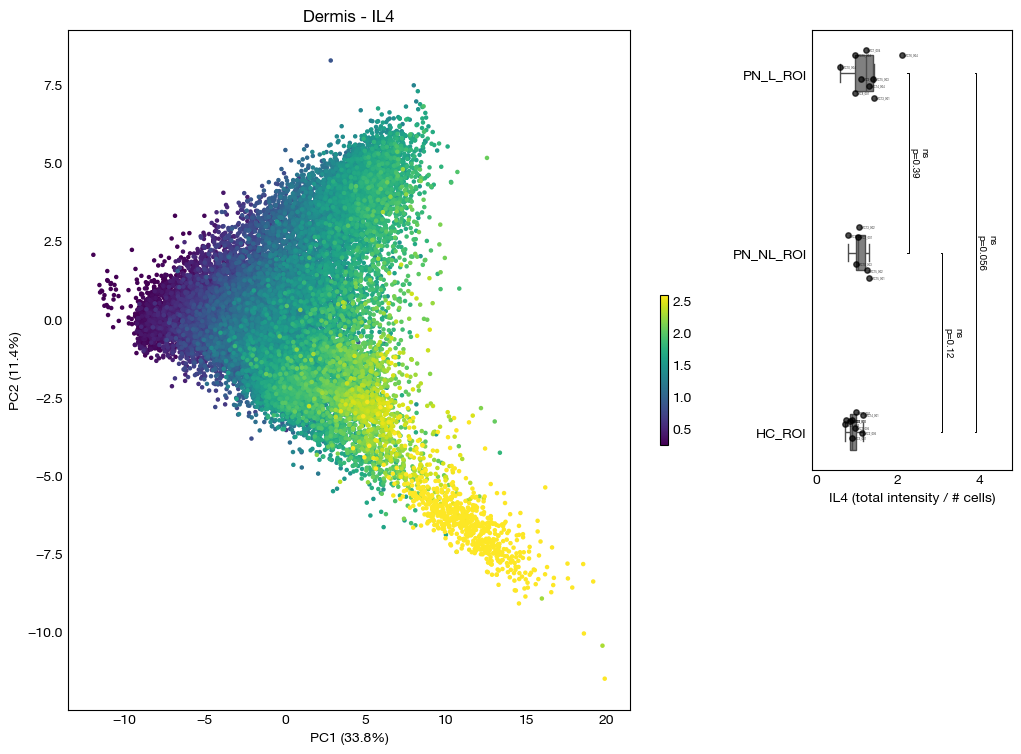

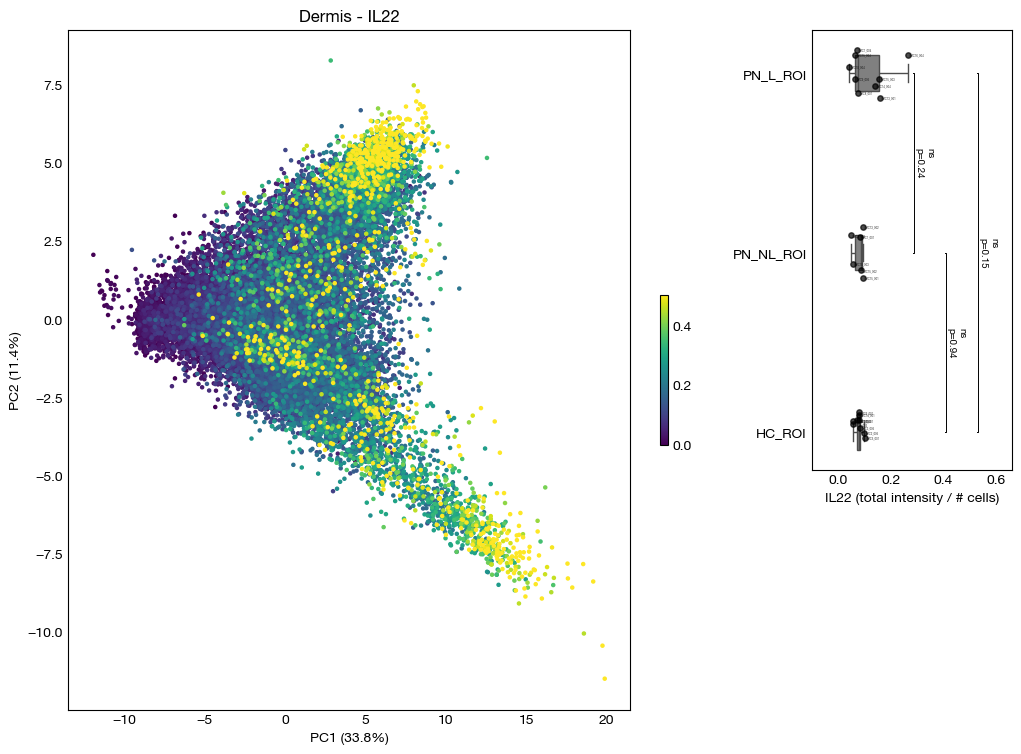

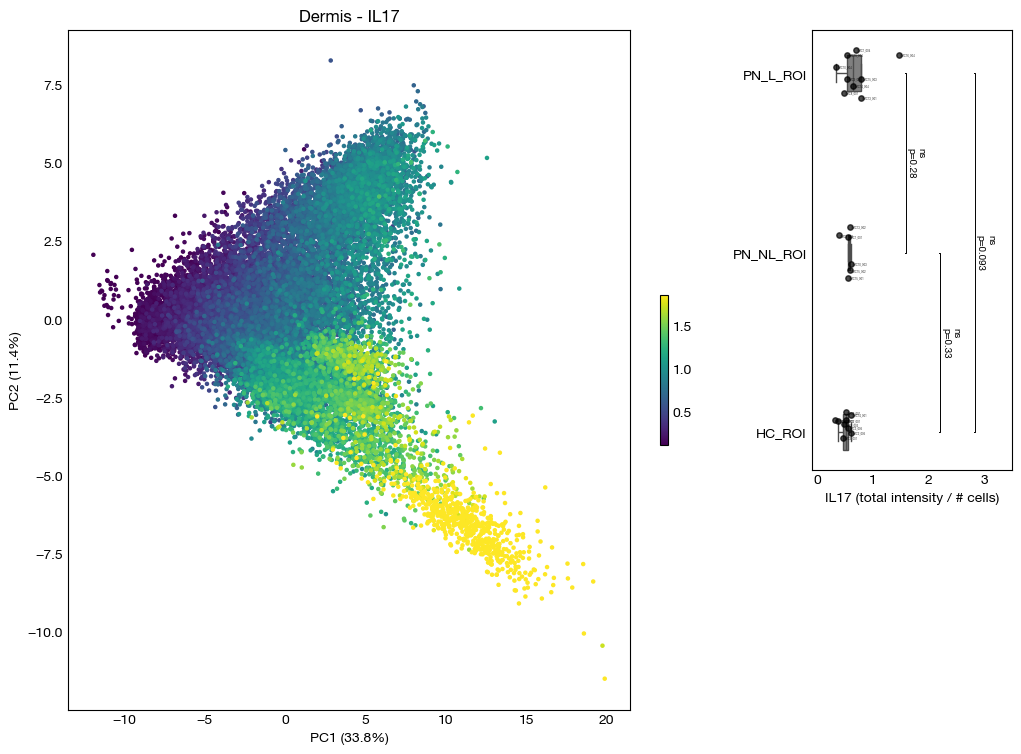

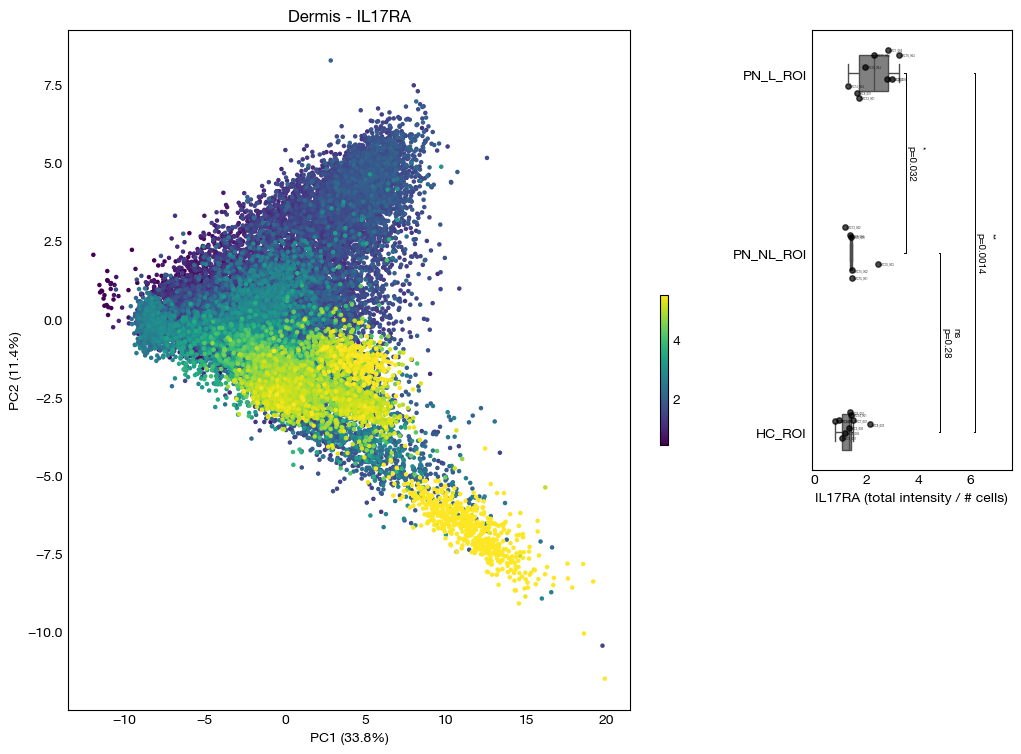

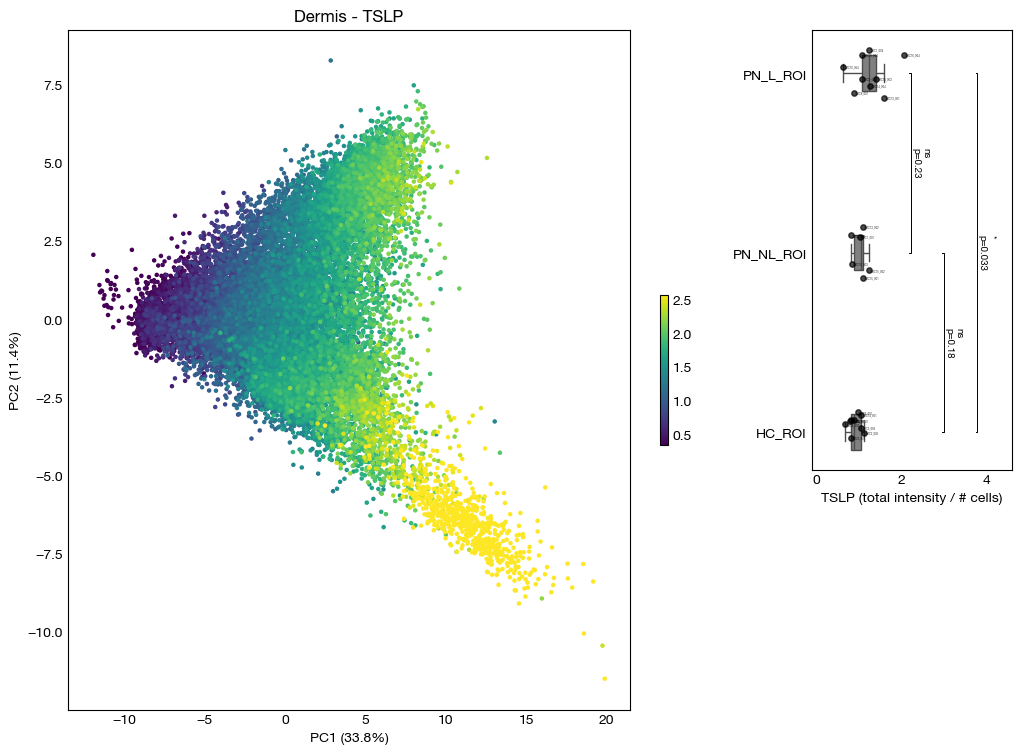

In [145]:
targets = ['IL4', 'IL22', 'IL17', 'IL17RA', 'TSLP']
for t in targets:
    #pca_box_target(t)
    #pca_box_target_es_d(t)
    #overlay_target(t)
    pca_box_target_es_d_ttest_norm(t)

In [126]:
markers = ['IL4', 'IL22', 'IL17', 'IL17RA', 'TSLP']

# ── ROI × marker matrix of mean intensities ─────────────────────────────
roi_summary = (dermal_cells
               .groupby(['roi', 'group'])[markers]
               .mean()
               .round(3)
               .reset_index())

# add avg rank across markers (low = consistently high across markers)
rank_cols = roi_summary[markers].rank(ascending=False, method='min')
roi_summary['avg_rank'] = rank_cols.mean(axis=1).round(1)

# sort by group, then by avg_rank within each group
roi_summary = roi_summary.sort_values(['group', 'avg_rank'])

print("=" * 80)
print("Per-ROI mean intensities (sorted by group, then by avg rank)")
print("=" * 80)
print(roi_summary.to_string(index=False))

# ── group-level summary ─────────────────────────────────────────────────
print("\n" + "=" * 80)
print("Group means")
print("=" * 80)
print(roi_summary.groupby('group')[markers].mean().round(3))

# ── top ROI per marker per group ────────────────────────────────────────
print("\n" + "=" * 80)
print("Top ROI per marker per group")
print("=" * 80)
for marker in markers:
    print(f"\n{marker}:")
    for grp, sub in roi_summary.groupby('group'):
        top = sub.nlargest(1, marker)
        print(f"  {grp:12s}: {top['roi'].iloc[0]} ({top[marker].iloc[0]:.3f})")


# ── lowest ROI per marker per group ────────────────────────────────────────
print("\n" + "=" * 80)
print("Lowest ROI per marker per group")
print("=" * 80)
for marker in markers:
    print(f"\n{marker}:")
    for grp, sub in roi_summary.groupby('group'):
        top = sub.nsmallest(1, marker)
        print(f"  {grp:12s}: {top['roi'].iloc[0]} ({top[marker].iloc[0]:.3f})")

print(roi_summary)
# ── save to CSV ─────────────────────────────────────────────────────────
#roi_summary.to_csv('roi_marker_means.csv', index=False)
#rint(f"\nSaved {len(roi_summary)} ROIs × {len(markers)} markers → roi_marker_means.csv")

Per-ROI mean intensities (sorted by group, then by avg rank)
      roi     group   IL4  IL22  IL17  IL17RA  TSLP  avg_rank
 IMC2_005    HC_ROI 1.115 0.098 0.605   1.158 1.117      10.0
IMC14_001    HC_ROI 1.143 0.080 0.609   1.418 1.050      10.6
 IMC3_005    HC_ROI 0.967 0.082 0.549   1.321 1.053      13.2
 IMC7_001    HC_ROI 0.889 0.080 0.516   1.476 0.885      15.0
 IMC6_001    HC_ROI 0.974 0.078 0.518   1.352 0.976      15.2
 IMC5_001    HC_ROI 0.871 0.104 0.469   1.064 0.809      17.2
 IMC8_003    HC_ROI 0.710 0.057 0.482   2.119 0.672      18.4
 IMC4_003    HC_ROI 0.743 0.071 0.320   0.945 0.808      21.2
IMC15_005    HC_ROI 0.845 0.058 0.364   0.790 0.790      21.6
IMC16_004  PN_L_ROI 2.113 0.267 1.474   3.255 2.071       1.0
IMC15_003  PN_L_ROI 1.402 0.157 0.776   2.776 1.417       3.2
IMC13_001  PN_L_ROI 1.426 0.161 0.785   1.725 1.593       3.4
 IMC1_004  PN_L_ROI 1.222 0.071 0.696   2.825 1.253       7.0
IMC14_004  PN_L_ROI 1.303 0.141 0.644   1.298 1.275       7.2
 IMC9_005

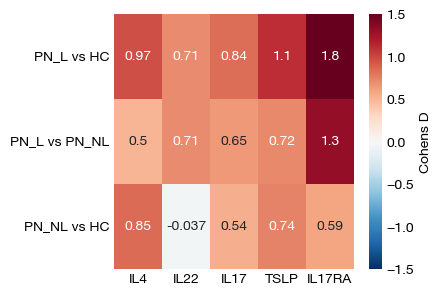

In [147]:
# make a heatmap of the associations
def cohens_d(a, b):
    """d = (mean_a - mean_b) / pooled_sd. Sign: + means a > b."""
    a, b = np.asarray(a), np.asarray(b)
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan


def effect_sizes(df, target, group_col='group',
                 z_order=['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']):
    """Per-ROI mean intensity, pairwise Cohen's d between groups."""
    roi_means = (df.groupby(['roi', group_col])[target]
                   .mean().reset_index(name='val'))
    
    pairs = [('PN_L_ROI', 'HC_ROI'),
             ('PN_L_ROI', 'PN_NL_ROI'),
             ('PN_NL_ROI', 'HC_ROI')]
    
    rows = []
    for a, b in pairs:
        va = roi_means.loc[roi_means[group_col] == a, 'val']
        vb = roi_means.loc[roi_means[group_col] == b, 'val']
        rows.append({
            'comparison': f'{a} vs {b}',
            'mean_a':     va.mean(),
            'mean_b':     vb.mean(),
            'fold':       va.mean() / vb.mean() if vb.mean() > 0 else np.nan,
            'cohens_d':   cohens_d(va, vb),
        })
    return pd.DataFrame(rows)

markers = ['IL4', 'IL22', 'IL17', 'TSLP','IL17RA']
ds = pd.DataFrame({m: effect_sizes(dermal_cells, m)['cohens_d'].values 
                   for m in markers},
                  index=['PN_L vs HC', 'PN_L vs PN_NL', 'PN_NL vs HC'])



# figure size
WIDTH = 4
HEIGHT = 3

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42

fig = plt.figure(figsize=(WIDTH, HEIGHT))

### add the axes
ax_heatmap = fig.add_axes([0.05, 0.05, 0.75, 0.85])

sns.heatmap(ds, annot=True, cmap='RdBu_r', center=0, vmin=-1.5, vmax=1.5, ax=ax_heatmap, cbar_kws={'label': 'Cohens D'})

fig.savefig(f'es_cohen-d2.pdf', bbox_inches='tight')


### Other checks

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_63302/2440657029.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cells_per_roi, x='group', y='n_cells',
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_63302/2440657029.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cells_per_roi, x='group', y='frac_dermal',


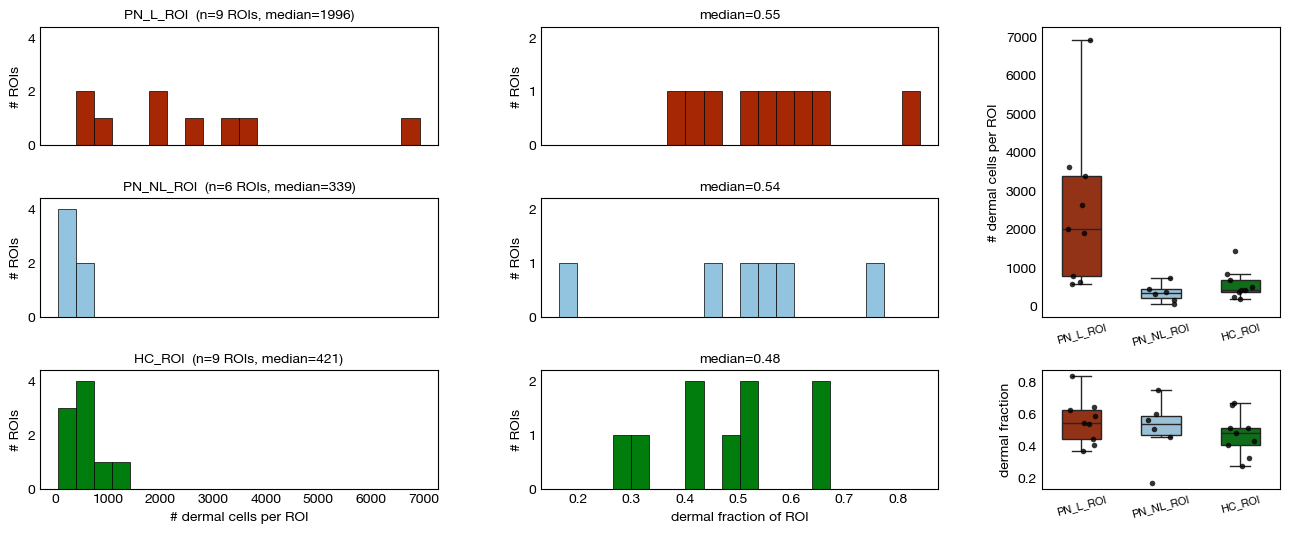

--- # dermal cells per ROI ---
           count    mean     std    min    25%     50%     75%     max
group                                                                 
HC_ROI       9.0   559.0   381.0  184.0  366.0   421.0   682.0  1421.0
PN_L_ROI     9.0  2489.0  2012.0  580.0  783.0  1996.0  3374.0  6923.0
PN_NL_ROI    6.0   345.0   234.0   57.0  199.0   339.0   429.0   724.0

--- dermal fraction per ROI ---
           count  mean   std   min   25%   50%   75%   max
group                                                     
HC_ROI       9.0  0.47  0.14  0.27  0.40  0.48  0.51  0.67
PN_L_ROI     9.0  0.55  0.14  0.37  0.44  0.55  0.62  0.84
PN_NL_ROI    6.0  0.51  0.19  0.16  0.47  0.54  0.59  0.75


In [128]:
#### distribution of cells per sample in each group

z_order   = ['PN_L_ROI', 'PN_NL_ROI', 'HC_ROI']
palette   = ['#a62703', '#92c4e0', '#017d0e']
color_map = dict(zip(z_order, palette))

# ── count cells per ROI per group ────────────────────────────────────────
cells_per_roi = (dermal_cells
                 .groupby(['roi', 'group'])
                 .size()
                 .reset_index(name='n_cells'))

total_per_roi = (all_cells
                 .groupby(['roi', 'group'])
                 .size()
                 .reset_index(name='n_total'))

cells_per_roi = cells_per_roi.merge(total_per_roi, on=['roi', 'group'])
cells_per_roi['frac_dermal'] = cells_per_roi['n_cells'] / cells_per_roi['n_total']

# ── figure: 3 rows × 3 cols (n_cells hist | frac_dermal hist | boxplots) ──
fig = plt.figure(figsize=(16, 6))
gs  = fig.add_gridspec(3, 3, width_ratios=[2, 2, 1.2],
                        hspace=0.45, wspace=0.3)

# helper to make stacked histograms with a shared x-axis and shared y-limit
def stack_histograms(col, value_col, xlabel, n_bins=20):
    bin_edges = np.histogram_bin_edges(cells_per_roi[value_col], bins=n_bins)
    max_count = max(
        np.histogram(cells_per_roi.loc[cells_per_roi['group'] == g, value_col],
                     bins=bin_edges)[0].max()
        for g in z_order
    )
    first_ax = None
    for i, group in enumerate(z_order):
        ax = fig.add_subplot(gs[i, col],
                              sharex=first_ax if first_ax else None)
        if first_ax is None: first_ax = ax
        subset = cells_per_roi[cells_per_roi['group'] == group]
        ax.hist(subset[value_col], bins=bin_edges,
                color=color_map[group], edgecolor='black', linewidth=0.5)
        ax.set_ylim(0, max_count * 1.1)
        ax.set_ylabel("# ROIs")
        if col == 0:
            med = subset[value_col].median()
            ax.set_title(f"{group}  (n={len(subset)} ROIs, "
                         f"median={med:.0f})", fontsize=10)
        else:
            med = subset[value_col].median()
            ax.set_title(f"median={med:.2f}", fontsize=10)
        if i < len(z_order) - 1:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel(xlabel)

# left: histograms of # dermal cells per ROI
stack_histograms(col=0, value_col='n_cells',
                 xlabel="# dermal cells per ROI")

# middle: histograms of % dermal cells per ROI
stack_histograms(col=1, value_col='frac_dermal',
                 xlabel="dermal fraction of ROI")

# right: boxplots — n_cells on top, frac_dermal on bottom
ax_box1 = fig.add_subplot(gs[:2, 2])
sns.boxplot(data=cells_per_roi, x='group', y='n_cells',
            order=z_order, palette=palette,
            width=0.5, fliersize=0, ax=ax_box1)
sns.stripplot(data=cells_per_roi, x='group', y='n_cells',
              order=z_order, color='black', size=4,
              alpha=0.8, jitter=0.18, ax=ax_box1)
ax_box1.set_ylabel("# dermal cells per ROI")
ax_box1.set_xlabel("")
ax_box1.tick_params(axis='x', labelrotation=15, labelsize=8)

ax_box2 = fig.add_subplot(gs[2, 2])
sns.boxplot(data=cells_per_roi, x='group', y='frac_dermal',
            order=z_order, palette=palette,
            width=0.5, fliersize=0, ax=ax_box2)
sns.stripplot(data=cells_per_roi, x='group', y='frac_dermal',
              order=z_order, color='black', size=4,
              alpha=0.8, jitter=0.18, ax=ax_box2)
ax_box2.set_ylabel("dermal fraction")
ax_box2.set_xlabel("")
ax_box2.tick_params(axis='x', labelrotation=15, labelsize=8)

plt.show()

# ── summary table for both metrics ───────────────────────────────────────
print("--- # dermal cells per ROI ---")
print(cells_per_roi.groupby('group')['n_cells'].describe()[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(0))

print("\n--- dermal fraction per ROI ---")
print(cells_per_roi.groupby('group')['frac_dermal'].describe()[
    ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(2))

       marker  r_epi  r_derm
         CD16   0.67    0.30
        CD11c   0.48    0.35
         CD45   0.47    0.35
         CD25   0.47    0.38
   SubstanceP   0.47    0.20
         IFNY   0.46    0.42
         TSLP   0.46    0.43
        TSLPR   0.44    0.32
NeuropeptideY   0.43    0.19
       IL22RA   0.40    0.19
          IL4   0.40    0.41
           5a   0.39    0.29
           Hg   0.38    0.19
        IL4RA   0.35    0.16
         IL13   0.32    0.20
         IL22   0.29    0.28
        102Ru   0.29   -0.18
        100Ru   0.29   -0.19
         CD31   0.29    0.04
         IL31   0.28    0.37
         IL17   0.27    0.38
          PD1   0.26    0.31
         CD14   0.25    0.30
       IL13RA   0.24    0.36
    Vanilloid   0.24    0.39
         CD20   0.23    0.21
           Cs   0.21    0.12
         LAG3   0.21    0.27
         TCTP   0.21    0.35
        CD163   0.19    0.04
          CD3   0.18    0.26
         CD15   0.15    0.20
         CD68   0.14    0.09
        STAT6 

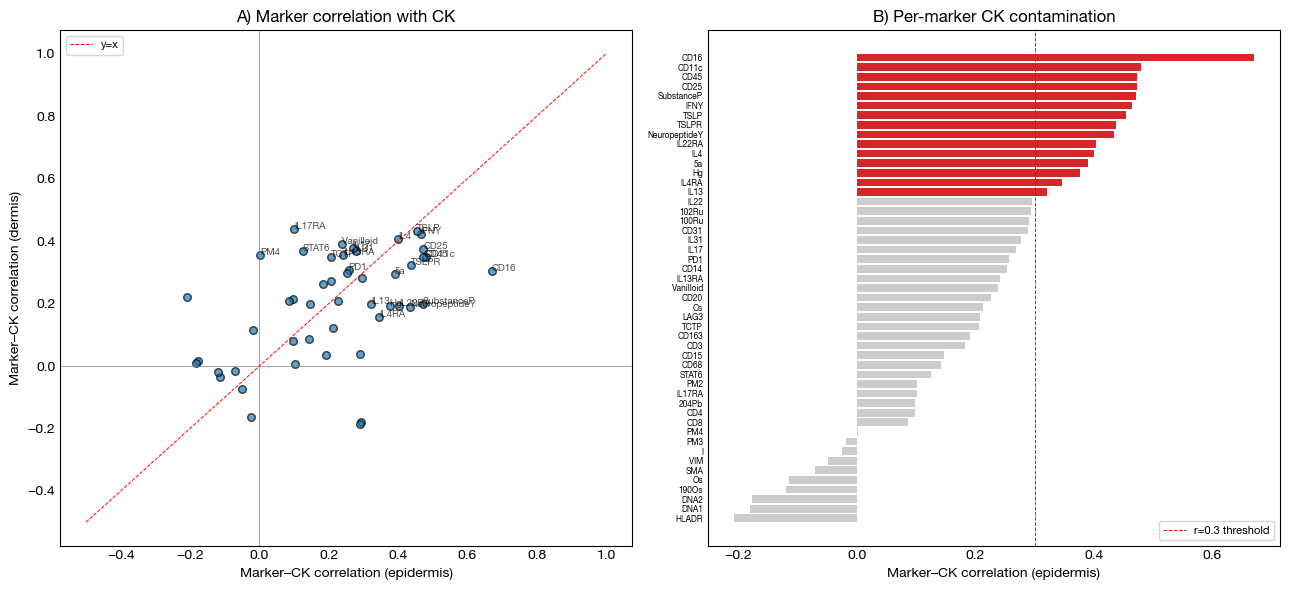

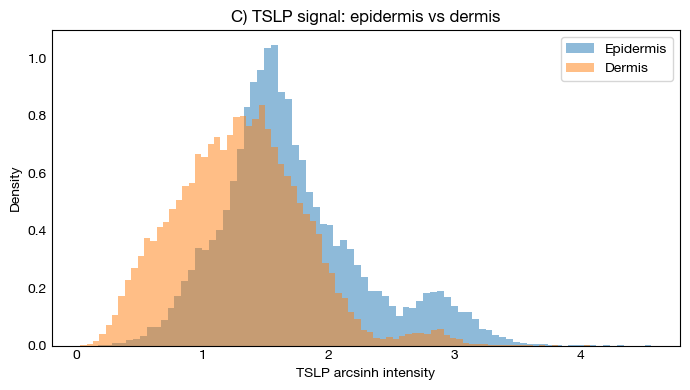

In [129]:
### confirming background signal

# ── 1. compute marker-vs-CK correlations across compartments ─────────────
def background_diagnostics(df, structural='CK', exclude=('roi', 'compartment', 'group')):
    markers = [c for c in df.columns if c not in exclude and c != structural]
    epi  = df[df['compartment'] == 'epidermis']
    derm = df[df['compartment'] == 'dermis']
    rows = []
    for m in markers:
        rows.append({
            'marker':  m,
            'r_epi':   np.corrcoef(epi[m],  epi[structural])[0, 1],
            'r_derm':  np.corrcoef(derm[m], derm[structural])[0, 1],
        })
    return pd.DataFrame(rows).sort_values('r_epi', ascending=False)

bg = background_diagnostics(all_cells, structural='CK')
print(bg.round(2).to_string(index=False))

# ── 2. summary stats ─────────────────────────────────────────────────────
print(f"\nMedian marker-CK correlation: "
      f"epi={bg['r_epi'].median():.2f}, derm={bg['r_derm'].median():.2f}")
print(f"% of markers with r > 0.3 in epi: "
      f"{100*(bg['r_epi'] > 0.3).mean():.0f}%")
print(f"% of markers with r > 0.3 in derm: "
      f"{100*(bg['r_derm'] > 0.3).mean():.0f}%")

# ── 3. two-panel figure: scatter of correlations + ranked bar chart ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# panel A: marker-CK correlation, epi vs derm
ax = axes[0]
ax.scatter(bg['r_epi'], bg['r_derm'], s=30, alpha=0.7, edgecolor='k')
for _, row in bg.iterrows():
    if abs(row['r_epi']) > 0.3 or abs(row['r_derm']) > 0.3:
        ax.annotate(row['marker'], (row['r_epi'], row['r_derm']),
                    fontsize=7, alpha=0.7)
ax.axhline(0, color='grey', lw=0.5); ax.axvline(0, color='grey', lw=0.5)
ax.plot([-0.5, 1], [-0.5, 1], color='red', ls='--', lw=0.7, label='y=x')
ax.set_xlabel('Marker–CK correlation (epidermis)')
ax.set_ylabel('Marker–CK correlation (dermis)')
ax.set_title('A) Marker correlation with CK')
ax.legend(fontsize=8)

# panel B: ranked bar chart of epi correlations
ax = axes[1]
bg_sorted = bg.sort_values('r_epi')
colors = ['#d62728' if r > 0.3 else '#cccccc' for r in bg_sorted['r_epi']]
ax.barh(bg_sorted['marker'], bg_sorted['r_epi'], color=colors, edgecolor='none')
ax.axvline(0.3, color='red', ls='--', lw=0.7, label='r=0.3 threshold')
ax.set_xlabel('Marker–CK correlation (epidermis)')
ax.set_title('B) Per-marker CK contamination')
ax.tick_params(axis='y', labelsize=6)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('background_diagnostic.pdf', bbox_inches='tight')
plt.show()

# ── 4. distribution overlay for one example marker ───────────────────────
TARGET = 'TSLP'   # change to highlight whichever marker is most affected
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(all_cells.loc[all_cells['compartment']=='epidermis', TARGET],
        bins=80, alpha=0.5, label='Epidermis', density=True)
ax.hist(all_cells.loc[all_cells['compartment']=='dermis', TARGET],
        bins=80, alpha=0.5, label='Dermis', density=True)
ax.set_xlabel(f'{TARGET} arcsinh intensity')
ax.set_ylabel('Density')
ax.set_title(f'C) {TARGET} signal: epidermis vs dermis')
ax.legend()
plt.tight_layout()
plt.savefig(f'{TARGET}_compartment_distribution.pdf', bbox_inches='tight')
plt.show()